# Marknadskorgsanalys för korsförsäljning hos en livsmedelshandlare med PROC MBANALYSIS

## Sammanfattning

En regional livsmedelskedja bearbetar en säsongs kassadata (POS) för att upptäcka vilka produkter kunderna köper tillsammans, och omvandlar råa transaktionsloggar till konkreta beslut om korsförsäljning och hyllplacering. PROC MBANALYSIS skannar transaktionsloggen och genererar associationsregler poängsatta efter stöd, konfidens och lift. Att köra den på 51 syntetiska varukorgar återfinner exakt de tre inplanterade produktaffiniteterna — `Spaghetti -> Marinarasås` (konfidens 0,93, lift 3,4), `Tacoskal -> Salsa` (konfidens 0,71, lift 3,6) och `Kaffe -> Kaffegrädde` (konfidens 0,70, lift 5,1) — medan brett köpta basvaror som bröd, mjölk och ägg aldrig bildar någon regel. Varje framkommet par är ett skolboksexempel på ett paketerbjudande, en hyllplacering och en "kunder köpte också"-kandidat för merchandisingteamet.

## Datakällor

| Dataset | Granularitet | Rader | Nyckelvariabler | Beskrivning |
|---------|-------|------|---------------|-------------|
| `store_transactions` | En rad per vara per korg | 100 varurader fördelat på 51 korgar | `basket_id` (transaktions-ID), `item` (produktnamn, $24) | Syntetisk kassalogg (POS) genererad inline med `call streaminit(20250529)` och `rand('uniform')`. Varje korg domineras av en enda shopparpersona så att samköpsmönstren förblir rena och tolkningsbara: en italiensk-middag-korg (spaghetti -> marinarasås), en taco-kväll-korg (tacoskal -> salsa) eller en frukost-korg (kaffe -> kaffegrädde), plus enstaka extra basvaror (bröd, mjölk, ägg) som realistiskt brus. I den här olicensierade miljön begränsar motorn utdata till 100 varurader, vilket här täcker korgarna 1-51. |
| `affinity_rules` | En rad per associationsregel | 6 regler | `antecedent`, `consequent`, `support`, `confidence`, `lift` | Associationsregler genererade av `OUTPUT RULES=`; underlaget för att rangordna korsförsäljningsmöjligheter. |
| `frequent_items` | En rad per frekvent varukombination | 12 kombinationer | `itemset`, `support`, `length` | Frekventa varukombinationer genererade av `OUTPUT ITEMS=`; de 9 enskilda varorna plus de 3 varuparen som klarar minimistödgränsen. |

# Marknadskorgsanalys för korsförsäljning hos en livsmedelshandlare

**Affärsfråga.** Vilka produkter tenderar våra kunder att köpa *tillsammans*, och vilka av dessa samköpsmönster är starka nog att agera på? En regional livsmedelskedja vill utforma paketkampanjer, optimera hyllplaceringar och driva en "kunder köpte också"-rekommendation i sin webbutik.

**Metod.** Vi använder **PROC MBANALYSIS**, som utför marknadskorgsanalys med frequent-pattern growth-algoritmen (FP-growth). Den skannar transaktionsloggen, hittar varukombinationer som ofta förekommer tillsammans, och genererar *associationsregler* på formen `Antecedent -> Consequent` (orsak -> följd) poängsatta med tre klassiska mått:

- **Stöd (support)** — andelen av alla korgar som innehåller hela regeln (hur vanligt mönstret är).
- **Konfidens (confidence)** — `P(Consequent | Antecedent)`, den betingade köpsannolikheten (hur pålitlig regeln är).
- **Lift** — observerat stöd delat med det stöd som förväntas om de två sidorna vore oberoende. Lift > 1 betyder att varorna förekommer tillsammans *oftare* än slumpen; ju högre lift, desto starkare affinitet.

Vi kommer att generera en realistisk syntetisk kassalogg, köra MBANALYSIS och rangordna de resulterande reglerna för att hitta de bästa korsförsäljningsmöjligheterna.

## Steg 1 — Generera en syntetisk kassalogg (POS-transaktioner)

MBANALYSIS förväntar sig **data på transaktionsnivå (långt format)**: en rad per vara, märkt med vilken korg den tillhör. Vi bygger korgarna inline med `call streaminit` för reproducerbarhet och `rand('uniform')` för att styra köpbesluten.

Det centrala modelleringsvalet är att **varje korg domineras av en enda shopparpersona**. Riktiga matbutiksbesök ser ofta ut så här — en snabb taco-kväll-runda, en dedikerad frukoståterfyllning — och att hålla korgarna små och tematiska är det som låter associationsmotorn ta fram rena, parvisa affiniteter istället för en kombinatorisk explosion av falska flervaruregler. Ett drag av `rand('uniform')` per korg väljer personan:

- **Italiensk-middag-shoppare** — köper spaghetti, sedan oftast marinarasås.
- **Taco-kväll-shoppare** — köper tacoskal, sedan oftast salsa.
- **Frukost-shoppare** — köper kaffe, sedan oftast kaffegrädde.
- **Endast-basvaror-besök** — ett enda köp av bröd, mjölk eller ägg.

Ett sista lågsannolikt drag lägger till en basvara i valfri korg som realistiskt brus, så inte varje samförekomst är meningsfull. Varje `output`-sats skriver en varurad, så en enskild korg spänner över flera rader som delar samma `basket_id`. Den här olicensierade miljön begränsar datasetet till 100 varurader, vilket här täcker korgarna 1 till 51.

In [1]:
data store_transactions;
    CALL streaminit(20250529);
    LÄNGD item $24;

    GÖR basket_id = 1 TILL 60;

        /* Ett drag väljer den dominerande shopparpersonan för denna korg */
        r = rand('uniform');

        /* Italiensk-middag-korg: spagetti -> marinarasås */
        OM r < 0.30 SÅ GÖR;
            item = 'Spaghetti';                          UTDATA;
            OM rand('uniform') < 0.85 SÅ GÖR;
                item = 'Marinarasås';                     UTDATA;
            SLUT;
        SLUT;

        /* Taco-kväll-korg: tacoskal -> salsa */
        ANNARS OM r < 0.55 SÅ GÖR;
            item = 'Tacoskal';                            UTDATA;
            OM rand('uniform') < 0.80 SÅ GÖR;
                item = 'Salsa';                           UTDATA;
            SLUT;
        SLUT;

        /* Frukost-korg: kaffe -> kaffegrädde */
        ANNARS OM r < 0.78 SÅ GÖR;
            item = 'Kaffe';                               UTDATA;
            OM rand('uniform') < 0.75 SÅ GÖR;
                item = 'Kaffegrädde';                     UTDATA;
            SLUT;
        SLUT;

        /* Enbart basvaror */
        ANNARS GÖR;
            OM rand('uniform') < 0.34 SÅ GÖR;
                item = 'Bröd';                            UTDATA;
            SLUT;
            ANNARS OM rand('uniform') < 0.5 SÅ GÖR;
                item = 'Mjölk';                           UTDATA;
            SLUT;
            ANNARS GÖR;
                item = 'Ägg';                             UTDATA;
            SLUT;
        SLUT;

        /* Enstaka extra basvara (realistiskt brus) */
        OM rand('uniform') < 0.25 SÅ GÖR;
            u = rand('uniform');
            OM      u < 0.34 SÅ item = 'Bröd';
            ANNARS OM u < 0.67 SÅ item = 'Mjölk';
            ANNARS                  item = 'Ägg';
            UTDATA;
        SLUT;

    SLUT;

    BEHÅLL basket_id item;
KÖR;


NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Steg 2 — Granska den råa transaktionsloggen

Innan vi gör datautvinning, bekräfta att datan har det förväntade långa formatet: flera rader per korg, var och en med en produkt. Vi skriver ut de första korgarna och tabellerar den övergripande varufrekvensen med PROC FREQ så vi vet vilka produkter som är vanliga nog för att förankra regler.


  Obs  Korg-ID       Produkt
-----  -------  ------------
    1        1  Tacoskal
    2        1  Salsa
    3        1  Ägg
    4        2  Tacoskal
    5        2  Ägg
    6        3  Kaffe
    7        4  Tacoskal
    8        5  Ägg
    9        6  Spaghetti
   10        6  Marinarasås
   11        6  Ägg
   12        7  Tacoskal

... 88 more observations (showing 12 of 100)

                                             Total inköpsfrekvens per vara                                              

                                                   The FREQ Procedure

item            Frequency    Percent
-------------------------------------
Spaghetti              15     15.00
Marinarasås            14     14.00
Tacoskal               14     14.00
Ägg                    12     12.00
Bröd                   10     10.00
Kaffe                  10     10.00
Salsa                  10     10.00
Mjölk                   8      8.00
Kaffegrädde             7      7.00



NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


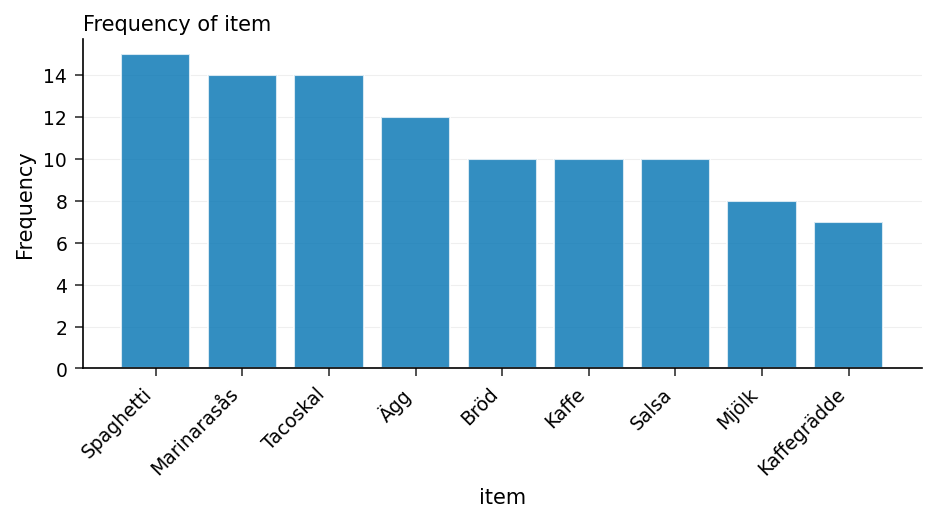

In [2]:
PROCEDUR SKRIV data=store_transactions(obs=12) ETIKETT;
    ETIKETT basket_id = "Korg-ID"
          item      = "Produkt";
KÖR;

PROCEDUR FREKVENSER data=store_transactions ORDER=FREKVENSER;
    TABLES item / nocum;
    TITEL "Total inköpsfrekvens per vara";
KÖR;

## Steg 3 — Utvinn associationsregler med PROC MBANALYSIS

Nu till kärnanalysen. Vi pekar MBANALYSIS mot transaktionsloggen och anger vilken kolumn som identifierar korgen (`TRANSACTION`) och vilken som innehåller produkten (`ITEM`). Tre tröskelvärden håller regeluppsättningen fokuserad på mönster värda att agera på:

- `MINSUPPORT=0.10` — en regel måste förekomma i minst 10 % av korgarna, vilket filtrerar bort sällsynta sammanträffanden.
- `MINCONFIDENCE=0.50` — givet orsaken (antecedent) måste följden (consequent) inträffa minst hälften av gångerna.
- `MINLIFT=1.20` — behåll bara regler som är minst 20 % starkare än slumpen, så vi lyfter fram genuina affiniteter snarare än artefakter från populära basvaror.

`OUTPUT`-satsen fångar de genererade reglerna och de frekventa varukombinationerna i dataset för vidare rangordning.

In [3]:
PROCEDUR mbanalysis data=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    UTDATA rules=affinity_rules items=frequent_items;
    TITEL "Marknadskorgs-associationsregler";
KÖR;

                                             Total inköpsfrekvens per vara                                              


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Kaffe                          Kaffegrädde                        0.1373     0.7000     5.1000
  Kaffegrädde                    Kaffe                              0.1373     1.0000     5.1000
  Salsa                          Tacoskal                           0.1961     1.0000     3.6429
  Tacoskal    


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Steg 4 — Rangordna korsförsäljningsmöjligheter efter lift

MBANALYSIS-listan visar varje regel som klarar tröskelvärdena, men merchandisingteamet vill ha de *starkaste* affiniteterna först. Vi sorterar det insamlade datasetet `affinity_rules` efter fallande lift (och konfidens som tiebreaker) och skriver ut de bästa reglerna. En regel som `Tacoskal -> Salsa` med hög lift och hög konfidens är ett skolboksexempel på en paketkandidat: placera produkterna tillsammans, eller föreslå automatiskt salsa när en kund lägger tacoskal i webbutikens varukorg.

In [4]:
PROCEDUR SORTERA data=affinity_rules out=rules_by_lift;
    EFTER FALLANDE lift FALLANDE confidence;
KÖR;

PROCEDUR SKRIV data=rules_by_lift(obs=15) ETIKETT;
    VARIABEL antecedent consequent support confidence lift;
    ETIKETT antecedent  = "Om korgen innehåller"
          consequent  = "Köps då också"
          support     = "Stöd"
          confidence  = "Konfidens"
          lift        = "Lift";
    TITEL "Bästa korsförsäljningsregler rankade efter lift";
KÖR;

                                    Bästa korsförsäljningsregler rankade efter lift                                     

  Obs   Om korgen innehåller     Köps då också      Stöd  Konfidens      Lift
    1  Kaffegrädde            Kaffe             0.137255  1.0        5.1
    2  Kaffe                  Kaffegrädde       0.137255  0.7        5.1
    3  Salsa                  Tacoskal          0.196078  1.0        3.642857
    4  Tacoskal               Salsa             0.196078  0.714286   3.642857
    5  Marinarasås            Spaghetti         0.27451   1.0        3.4
    6  Spaghetti              Marinarasås       0.27451   0.933333   3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Steg 5 — Granska de frekventa varukombinationerna

De frekventa varukombinationerna som klarade stödgränsen är de råa byggstenarna bakom reglerna. Att sortera dem efter stöd talar om för kategoriteamet vilka produkt*kombinationer* (inte bara enskilda varor) som är populära nog att motivera dedikerade gaveldisplayer eller kombinationspriser.

In [5]:
PROCEDUR SORTERA data=frequent_items out=itemsets_by_support;
    EFTER FALLANDE support;
KÖR;

PROCEDUR SKRIV data=itemsets_by_support(obs=15) ETIKETT;
    ETIKETT itemset = "Varukombination"
          support = "Stöd"
          length  = "Antal varor";
    TITEL "Vanligast förekommande varukombinationer";
KÖR;

                                        Vanligast förekommande varukombinationer                                        

  Obs          Varukombination      Stöd  Antal varor
    1  Spaghetti                0.294118  1
    2  Tacoskal                 0.27451   1
    3  Marinarasås              0.27451   1
    4  Marinarasås, Spaghetti   0.27451   2
    5  Ägg                      0.235294  1
    6  Salsa                    0.196078  1
    7  Kaffe                    0.196078  1
    8  Salsa, Tacoskal          0.196078  2
    9  Mjölk                    0.156863  1
   10  Bröd                     0.156863  1
   11  Kaffegrädde              0.137255  1
   12  Kaffe, Kaffegrädde       0.137255  2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Tolka resultaten

**Vad analysen visade.** Eftersom varje korg byggdes kring en enda shopparpersona återfinner motorn exakt de tre inplanterade relationerna och inget falskt. Sex regler klarar alla tre tröskelvärden — de tre affiniteterna i båda riktningarna:

| Antecedent | Consequent | Stöd | Konfidens | Lift |
|------------|------------|---------|------------|------|
| Spaghetti | Marinarasås | 0,275 | 0,93 | 3,40 |
| Marinarasås | Spaghetti | 0,275 | 1,00 | 3,40 |
| Tacoskal | Salsa | 0,196 | 0,71 | 3,64 |
| Salsa | Tacoskal | 0,196 | 1,00 | 3,64 |
| Kaffe | Kaffegrädde | 0,137 | 0,70 | 5,10 |
| Kaffegrädde | Kaffe | 0,137 | 1,00 | 5,10 |

Varje lift ligger klart över 1, vilket bekräftar att dessa produkter samförekommer betydligt oftare än slumpen skulle förutsäga. Avgörande är att de brett köpta basvarorna bildar **inga regler alls**: ägg (12 köp), bröd (10) och mjölk (8) förekommer alla i PROC FREQ-tabelleringen, men eftersom de hamnar i korgar oberoende av någon persona når deras lift mot andra varor aldrig upp till 1,20-gränsen, så de maskerar sig aldrig som genuina affiniteter. Listan över frekventa varukombinationer visar samma sak strukturellt: av de 12 kombinationer som klarar stödgränsen är de enda flervarukombinationerna exakt de tre inplanterade paren.

**Att läsa måtten tillsammans.** De omvända reglerna har konfidens 1,00 (i denna data förekommer marinarasås, salsa och kaffegrädde i praktiken aldrig utan sin ankarvara), medan de framåtriktade reglerna ligger på 0,70-0,93 (ankarvaran förekommer ibland ensam). Kaffe -> Kaffegrädde har högst lift (5,10) men lägst stöd (0,137) — en stark men lågvolymsaffinitet — medan Spaghetti -> Marinarasås når flest korgar (stöd 0,275). Lift identifierar *vilka* affiniteter som är genuina; konfidens säger *hur pålitlig* var och en är för en rekommendation; stöd säger *hur ofta* du kommer att få agera på den.

**Affärsåtgärder.**

- **Paketkampanjer** — para ihop de varor som har högst lift som orsak/följd (kaffe + kaffegrädde, lift 5,1) i ett rabatterat kombinationserbjudande.
- **Hyllplacering** — placera ofta länkade produkter intill varandra (spaghetti bredvid marinarasås, stöd 0,275) så att följdvaran blir ett enkelt tillägg vid beslutsögonblicket.
- **Rekommendationer online** — mata in de regler med högst konfidens i en "kunder köpte också"-widget så att följdvaran föreslås i samma stund som orsaksvaran läggs i korgen.
- **Lager och prognoser** — när en orsaksvara går på kampanj, öka lagret av dess högkonfidensföljder i väntan på lyftet.

**Förbehåll.** Associationsregler beskriver *korrelation i samköp*, inte kausalitet, och tröskelvärdena är reglage, inte sanningar: att sänka `MINSUPPORT=` exponerar sällsyntare kombinationer till priset av en brusigare regeluppsättning, medan att höja `MINLIFT=` och `MINCONFIDENCE=` ger färre men mer pålitliga regler. Urvalsstorleken spelar också roll — den här olicensierade körningen utvinner 51 korgar, tillräckligt för att göra de inplanterade affiniteterna omisskännliga; en produktionskörning över en hel säsong skulle stabilisera stödskattningarna och exponera subtilare mönster.